[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hendersonneurolab/CogAI_Fall2025/blob/master/Lab01_Intro_CNN.ipynb)

## Lab Exercise 1: Convolutional Neural Networks (CNNs)

In this tutorial, we'll work with convolutional neural networks. We will:

1. Construct a simple CNN using PyTorch and train it on the Fashion-MNIST dataset.
2. Investigate the error patterns of our network.

**Learning objectives:**
- Get basic familiarity with PyTorch
- Understand the key steps involved in neural network training
- Understand the inputs and outputs to an image classifier

More info about PyTorch and related tutorials can be found here:
https://docs.pytorch.org/tutorials/beginner/basics/intro.html


# Lab 1: Introduction to CNNs

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import time
import requests
from PIL import Image

# Check if CUDA (GPU) is available - this will speed up training significantly
# If it says "cpu", use the menu at top right to select: "change runtime type"
# Then choose: T4 GPU

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')



Using device: cuda
GPU: Tesla T4


**Step 1: Preparing the data**

In PyTorch, there are several image datasets conveniently available by default. Fashion-MNIST is one of these: it includes images of clothing items in different categories. We're going to create a "dataloader" object that helps us organize the image data for model training.


In [ ]:
# Fashion-MNIST has 10 classes of clothing items
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def prepare_data(batch_size=128):
    """
    Prepares the Fashion-MNIST dataset for training and testing.
    """

    # Data preprocessing pipeline
    # Here we're creating a set of "transforms". These are functions that get
    # applied to each image, before it goes into the CNN.
    transform = transforms.Compose([
        transforms.ToTensor(),                    # Convert to tensor [0,1]
        transforms.Normalize((0.2860,), (0.3530,))  # Normalize to mean=0, std=1
    ])
    # Why these transforms?
    # - ToTensor(): Converts PIL images to PyTorch tensors and scales from [0,255] to [0,1]
    # - Normalize(): Centers the data around 0, which helps neural networks train better
    #   The values (0.2860,) and (0.3530,) are the mean and std of Fashion-MNIST


    # Download and load training data
    # We're making a dataset object here - this holds information about the image files.
    # Fashion-MNIST: 60,000 training images, 10,000 test images, 28x28 pixels each
    # Here, we're just downloading the image files to a temp directory that will be deleted when your colab session ends.
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data',
        # root=my_root,
        train=True,
        download=True,        # Downloads dataset if not present
        transform=transform
    )

    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data',
        # root=my_root,
        train=False,
        download=True,
        transform=transform
    )

    # Create DataLoader here.
    # DataLoader is created from the dataset object.
    # It handles batching, shuffling, and parallel loading
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,         # Shuffle training data each epoch
        num_workers=2,        # Parallel data loading (adjust based on your CPU)
        pin_memory=True       # Speeds up GPU transfer
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,        # No need to shuffle test data
        num_workers=2,
        pin_memory=True
    )

    return train_loader, test_loader, train_dataset, test_dataset


# Here we call the above function, making our dataset and dataloader objects.
train_loader, test_loader, train_dataset, test_dataset = prepare_data(batch_size=128)



In [ ]:
# Check out what's in the datasets...how big are they?
train_dataset, test_dataset

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=(0.286,), std=(0.353,))
            ),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=(0.286,), std=(0.353,))
            ))

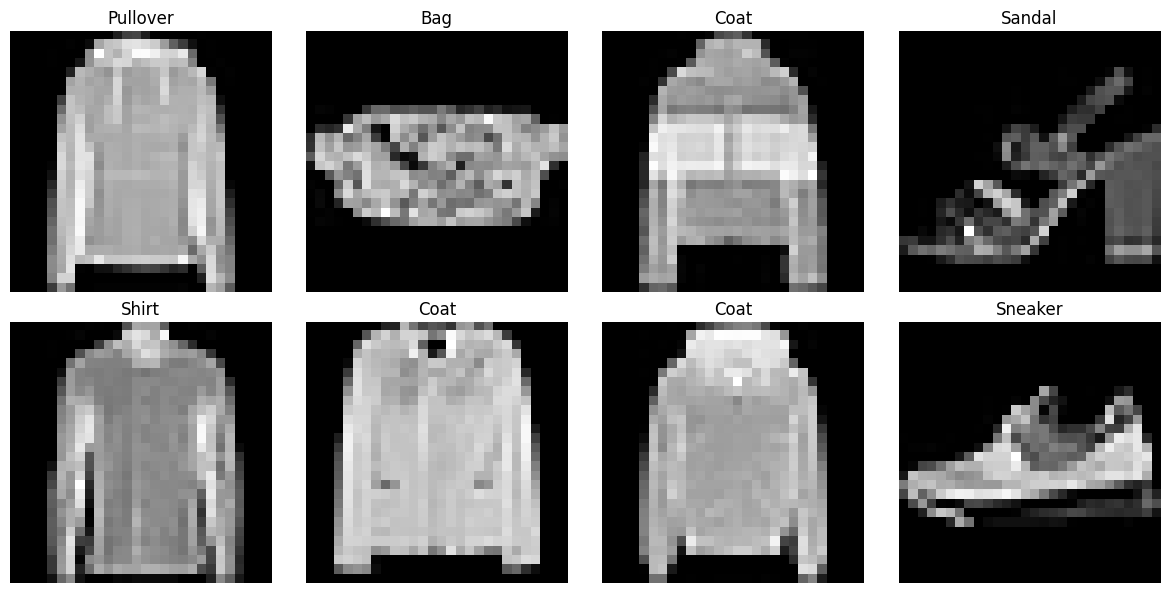

Image shape: torch.Size([1, 28, 28])
Batch shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])


In [ ]:

def visualize_data(train_loader, num_samples=8):
    """
    Visualizes some sample images from the dataset to understand what we're working with.
    """
    # Get one batch of data
    dataiter = iter(train_loader)
    images, labels = next(dataiter)

    # Create a grid of subplots
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()

    for i in range(num_samples):
        # Convert tensor back to numpy for visualization
        # We need to denormalize: pixel = (normalized_pixel * std) + mean
        img = images[i].squeeze()
        img = img * 0.3530 + 0.2860  # Denormalize
        img = torch.clamp(img, 0, 1)  # Ensure values are in [0,1]

        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'{class_names[labels[i]]}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Image shape: {images[0].shape}")  # Should be [1, 28, 28]
    print(f"Batch shape: {images.shape}")     # Should be [batch_size, 1, 28, 28]
    print(f"Labels shape: {labels.shape}")    # Should be [batch_size]

visualize_data(train_loader, num_samples=8)

**Step 2: Define the CNN model**

We will create the architecture of the model here. The building blocks come from the "nn" module in PyTorch. The model consists of hierarchical layers: convolutional layers, followed by a nonlinearity (ReLU), followed by maxpooling layers. Last, there is a series of fully connected layers.

The model is created as a "FashionCNN" object. It has a method called "forward". The forward method is what gets used when you run the FashionCNN model. For example if you run: FashionCNN(x), x will be input to the forward method.

In [ ]:

class FashionCNN(nn.Module):
    """
    Our Convolutional Neural Network for Fashion-MNIST classification.

    Architecture breakdown:
    - 2 Convolutional blocks (Conv -> ReLU -> MaxPool)
    - 3 Fully connected layers with dropout for regularization
    - Output layer with 10 units (one for each class)
    """

    def __init__(self):
        super(FashionCNN, self).__init__()

        # ====================================================================
        # CONVOLUTIONAL LAYERS
        # ====================================================================

        # First convolutional block
        # Input: 1x28x28 (1 channel, 28x28 pixels)
        self.conv1 = nn.Conv2d(
            in_channels=1,      # Grayscale images have 1 channel
            out_channels=32,    # We want 32 feature maps
            kernel_size=3,      # 3x3 filters
            padding=1           # Padding to maintain spatial dimensions
        )
        # After conv1: 32x28x28
        # After maxpool1: 32x14x14

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,    # More feature maps for richer representations
            kernel_size=3,
            padding=1
        )
        # After conv2: 64x14x14
        # After maxpool2: 64x7x7

        # Max pooling reduces spatial dimensions by half
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ====================================================================
        # FULLY CONNECTED LAYERS
        # ====================================================================

        # Calculate input size for first linear layer
        # After 2 max pooling operations: 28 -> 14 -> 7
        # So we have 64 feature maps of size 7x7 = 64 * 7 * 7 = 3136

        self.fc1 = nn.Linear(64 * 7 * 7, 128)   # First hidden layer
        self.fc2 = nn.Linear(128, 64)            # Second hidden layer
        self.fc3 = nn.Linear(64, 10)             # Output layer (10 classes)

        # Dropout for regularization - randomly sets some neurons to 0 during training
        # This prevents overfitting by making the model more robust
        # self.dropout = nn.Dropout(0.5)  # 50% dropout rate
        self.dropout = nn.Dropout(0.1)  # 10% dropout rate

    def forward(self, x):
        """
        Forward pass through the network.
        This defines how data flows through our model.
        """

        # First convolutional block: Conv -> ReLU -> MaxPool
        x = self.pool(F.relu(self.conv1(x)))  # [batch, 32, 14, 14]

        # Second convolutional block: Conv -> ReLU -> MaxPool
        x = self.pool(F.relu(self.conv2(x)))  # [batch, 64, 7, 7]

        # Flatten for fully connected layers
        # View reshapes the tensor: -1 means "infer this dimension"
        x = x.view(-1, 64 * 7 * 7)  # [batch, 3136]

        # First fully connected layer with ReLU and dropout
        x = F.relu(self.fc1(x))     # [batch, 128]
        x = self.dropout(x)         # Apply dropout (only during training)

        # Second fully connected layer with ReLU and dropout
        x = F.relu(self.fc2(x))     # [batch, 64]
        x = self.dropout(x)

        # Output layer - no activation here, we'll use CrossEntropyLoss
        # CrossEntropyLoss applies softmax internally
        x = self.fc3(x)             # [batch, 10]

        return x



Quick test of the model: just pass one batch of images in.

In [ ]:

# Make our CNN: it's an instance of this model class.
model = FashionCNN()

# Get one batch of data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Forward pass: put images into model, get predictions
output = model(images)

print(output.shape)
# output contains the predicted probability assigned to each class by the model.
# [128 x 10]
# 128 = image batch size
# 10 = number of clases

torch.Size([128, 10])



---

***Question 1:***

Try writing some code to compute the accuracy of the model on this batch. How well did its predicted labels align with the real labels?

Hint: Use the variables "output" and "labels". To get the predicted labels, we want to find the category the model assigned the highest probabilty to.



---



In [ ]:

# which category did the model think the images were in?
predicted_labels = torch.argmax(output, dim=1)

# How accurate are the predictions?
# Keep in mind this model hasn't been trained, so it's not very good yet.
acc = torch.mean((predicted_labels==labels).float())

print('Accuracy: %.4f'%(acc.item()))

**Step 3: Create training and evaluation procedures**

Now we will create the functions needed for model training.

Reminder of some key terms here:

- Batch = a group of images that are processed together by the CNN.
- Step = processing one batch of images (includes forward pass, computing loss, computing gradients, and updating weights).
- Epoch = one pass over the entire training dataset (includes multiple steps).



In [ ]:


def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Trains the model for one epoch (one pass through all training data).

    Returns:
        avg_loss: Average loss for this epoch
        accuracy: Training accuracy for this epoch
    """
    model.train()  # Set model to training mode (enables dropout, batch norm, etc.)

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # tqdm creates a progress bar
    progress_bar = tqdm(train_loader, desc='Training', leave=False)

    for batch_idx, (data, target) in enumerate(progress_bar):
        # Move data to GPU if available
        data, target = data.to(device), target.to(device)

        # Zero the gradients from the previous batch
        # PyTorch accumulates gradients by default
        optimizer.zero_grad()

        # Forward pass: compute predictions
        output = model(data)

        # Compute loss
        # Here, this is based on cross-entropy loss.
        # It's a measure of how well the output probabilities have captured
        # the actual labels.
        loss = criterion(output, target)

        # Backward pass: compute gradients
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics for monitoring
        running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)  # Get class with highest probability
        total_samples += target.size(0)
        correct_predictions += (predicted == target).sum().item()

        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100. * correct_predictions / total_samples:.2f}%'
        })

    avg_loss = running_loss / len(train_loader)
    accuracy = 100. * correct_predictions / total_samples

    return avg_loss, accuracy



In [ ]:

def evaluate_epoch(model, test_loader, criterion, device):
    """
    Evaluates the model on test data.

    Returns:
        avg_loss: Average test loss
        accuracy: Test accuracy
        class_accuracies: Accuracy for each class
    """
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)

    test_loss = 0
    correct = 0
    total = 0

    # Track predictions for each class
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))

    with torch.no_grad():  # Disable gradient computation for faster inference
        for data, target in tqdm(test_loader, desc='Evaluating', leave=False):
            data, target = data.to(device), target.to(device)

            output = model(data)
            test_loss += criterion(output, target).item()

            _, predicted = torch.max(output, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

            # Per-class accuracy
            c = (predicted == target).squeeze()
            for i in range(target.size(0)):
                label = target[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    avg_loss = test_loss / len(test_loader)
    accuracy = 100. * correct / total

    # Calculate per-class accuracies
    class_accuracies = []
    for i in range(10):
        if class_total[i] > 0:
            class_acc = 100. * class_correct[i] / class_total[i]
            class_accuracies.append(class_acc)
        else:
            class_accuracies.append(0.0)

    return avg_loss, accuracy, class_accuracies



**Step 4: Run the training procedure**


Here we will train the model for a number of epochs. We will use the training and eval functions that we just defined.

Reminder of key terms here:

- Loss: a measure of how badly the model has done on our task. Here, it's a classification task, so it captures classification accuracy, but in other scenarios it could capture some other task. The goal of training is to make the loss as low as possible.
- Gradients: for each model parameter, which direction should we change it to improve the model's loss?
- Optimizer: an algorithm that defines how we will update weights based on gradients, to improve loss.


Note: this cell can take a while to run, especially if you're using a CPU. Make sure you connect to the GPU, and it should take <5 minutes.

In [ ]:

# num_epochs = 10;
num_epochs = 5;
learning_rate = 0.001;

# Move model to GPU if available
model = model.to(device)

# Define loss function and optimizer
# CrossEntropyLoss combines softmax and negative log-likelihood
# It's perfect for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer - adaptive learning rate, works well in practice
# Alternative: SGD with momentum
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Optional: Learning rate scheduler
# Reduces learning rate when loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 'min', patience=2, factor=0.5, verbose=True
)

# Track training history
train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

# Evaluate on train and test set - before any training.
train_loss, train_acc, train_class_accs = evaluate_epoch(model, train_loader, criterion, device)
test_loss, test_acc, class_accs = evaluate_epoch(model, test_loader, criterion, device)


# Record history
train_losses.append(train_loss)
train_accuracies.append(train_acc)
test_losses.append(test_loss)
test_accuracies.append(test_acc)

# Print epoch results
print(f'Before training - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
print(f'Before training - Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')


print(f"\nStarting training for {num_epochs} epochs...")
print(f"Training on {device}")

start_time = time.time()

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)

    # Train for one epoch
    train_loss_running, train_acc_running = train_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate on train and test set
    train_loss, train_acc, train_class_accs = evaluate_epoch(model, train_loader, criterion, device)
    test_loss, test_acc, class_accs = evaluate_epoch(model, test_loader, criterion, device)

    # Update learning rate scheduler
    scheduler.step(test_loss)

    # Record history
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    # Print epoch results
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

    # Print per-class accuracies every few epochs
    if (epoch + 1) % 5 == 0:
        print("\nPer-class accuracies:")
        for i, acc in enumerate(class_accs):
            print(f'{class_names[i]}: {acc:.2f}%')

total_time = time.time() - start_time
print(f'\nTraining completed in {total_time:.2f} seconds')

# return {
#     'train_losses': train_losses,
#     'train_accuracies': train_accuracies,
#     'test_losses': test_losses,
#     'test_accuracies': test_accuracies
# }



/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Before training - Train Loss: 2.3038, Train Acc: 11.78%
Before training - Test Loss: 2.3038, Test Acc: 11.93%

Starting training for 5 epochs...
Training on cuda

Epoch 1/5
--------------------------------------------------


Train Loss: 0.3174, Train Acc: 88.45%
Test Loss: 0.3438, Test Acc: 87.59%

Epoch 2/5
--------------------------------------------------


Train Loss: 0.2719, Train Acc: 89.96%
Test Loss: 0.3092, Test Acc: 88.41%

Epoch 3/5
--------------------------------------------------


Train Loss: 0.2234, Train Acc: 91.79%
Test Loss: 0.2684, Test Acc: 90.26%

Epoch 4/5
--------------------------------------------------


Train Loss: 0.2125, Train Acc: 92.11%
Test Loss: 0.2665, Test Acc: 90.24%

Epoch 5/5
--------------------------------------------------


Train Loss: 0.1685, Train Acc: 93.95%
Test Loss: 0.2332, Test Acc: 91.36%

Per-class accuracies:
T-shirt/top: 86.50%
Trouser: 99.00%
Pullover: 87.70%
Dress: 90.00%
Coat: 85.10%
Sandal: 98.30%
Shirt: 75.90%
Sneaker: 96.40%
Bag: 98.50%
Ankle boot: 96.20%

Training completed in 174.79 seconds


In [ ]:
train_loader.batch_size

128

In [ ]:
# Getting the final performance of the model, once it's fully trained

_, final_accuracy, class_accuracies = evaluate_epoch(model, test_loader, nn.CrossEntropyLoss(), device)

print(f"\nFinal test accuracy: {final_accuracy:.2f}%")

print("\nPer-class accuracies:")
for i, acc in enumerate(class_accuracies):
    print(f"{class_names[i]}: {acc:.2f}%")



Final test accuracy: 91.36%

Per-class accuracies:
T-shirt/top: 86.50%
Trouser: 99.00%
Pullover: 87.70%
Dress: 90.00%
Coat: 85.10%
Sandal: 98.30%
Shirt: 75.90%
Sneaker: 96.40%
Bag: 98.50%
Ankle boot: 96.20%


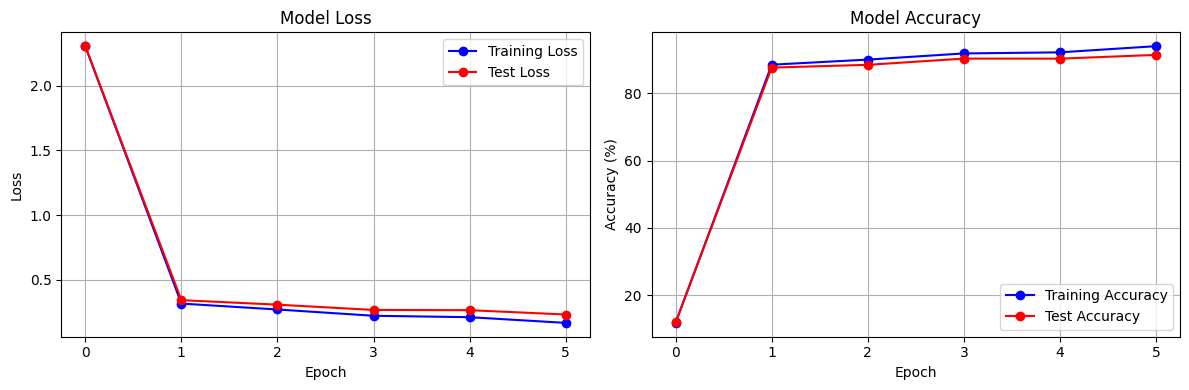

In [ ]:
# Visualize the model's training progress over time

def plot_training_history(history):
    """
    Plots training and validation curves.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss curve
    epochs = range(0, len(history['train_losses']))
    ax1.plot(epochs, history['train_losses'], 'bo-', label='Training Loss')
    ax1.plot(epochs, history['test_losses'], 'ro-', label='Test Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy curve
    ax2.plot(epochs, history['train_accuracies'], 'bo-', label='Training Accuracy')
    ax2.plot(epochs, history['test_accuracies'], 'ro-', label='Test Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

history = {
    'train_losses': train_losses,
    'train_accuracies': train_accuracies,
    'test_losses': test_losses,
    'test_accuracies': test_accuracies
}
plot_training_history(history)

**Step 5: Analyze error patterns**

Now that the model is trained, let's look at the predictions in more detail.

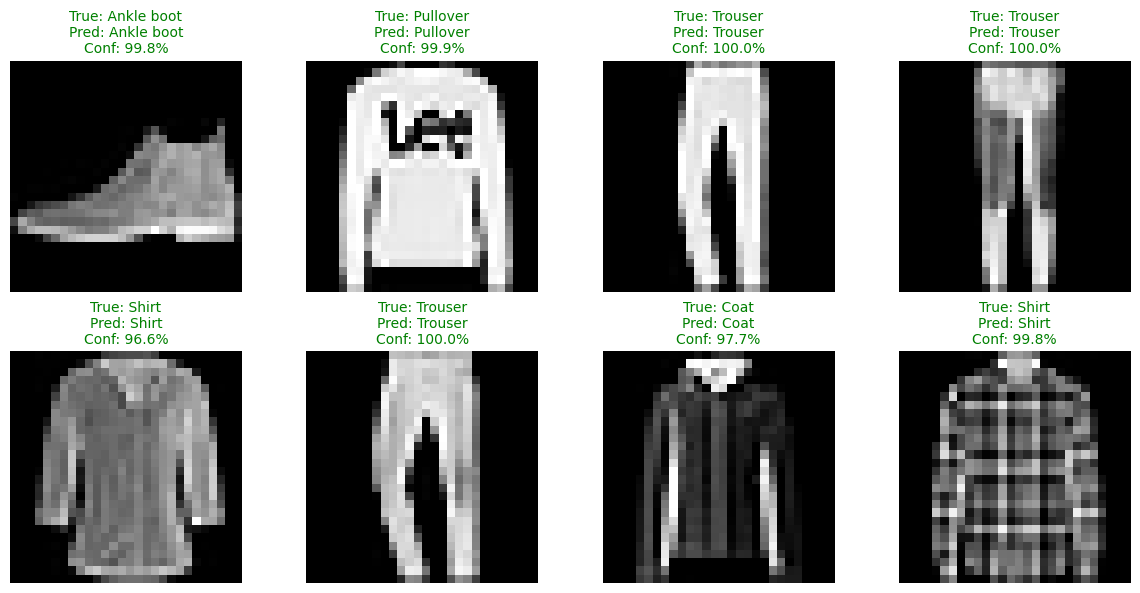

In [ ]:
# Visualize model predictions on test images.

num_images=8

model.eval()

# Get a batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Make predictions
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    # Get prediction probabilities
    probabilities = F.softmax(outputs, dim=1)

# Move back to CPU for visualization
images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()
probabilities = probabilities.cpu()

# Plot results
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i in range(num_images):
    # Denormalize image for display
    img = images[i].squeeze()
    img = img * 0.3530 + 0.2860
    img = torch.clamp(img, 0, 1)

    # Plot image
    axes[i].imshow(img, cmap='gray')

    # Create title with prediction info
    true_label = class_names[labels[i]]
    pred_label = class_names[predicted[i]]
    confidence = probabilities[i][predicted[i]] * 100

    color = 'green' if predicted[i] == labels[i] else 'red'
    title = f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%'

    axes[i].set_title(title, color=color, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


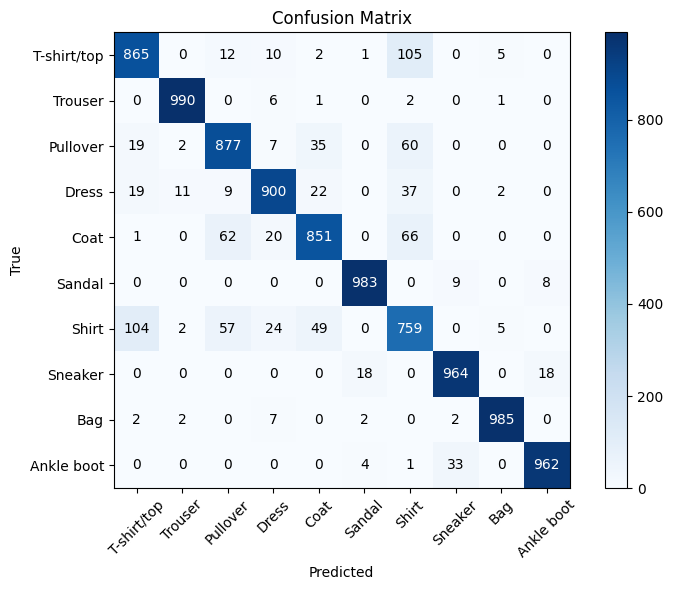

Most common classification mistakes:
T-shirt/top → Shirt: 105 mistakes
Shirt → T-shirt/top: 104 mistakes
Coat → Shirt: 66 mistakes
Coat → Pullover: 62 mistakes
Pullover → Shirt: 60 mistakes


In [ ]:
# Analyze the most common mistakes made by the model.

model.eval()

confusion_matrix = torch.zeros(10, 10)

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output, 1)

        # Build confusion matrix
        for t, p in zip(target.view(-1), predicted.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, cmap='Blues')
plt.colorbar()

# Add labels and numbers
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

# Add text annotations
for i in range(10):
    for j in range(10):
        plt.text(j, i, f'{int(confusion_matrix[i, j])}',
                ha='center', va='center',
                color='white' if confusion_matrix[i, j] > confusion_matrix.max()/2 else 'black')

plt.tight_layout()
plt.show()

# Print most common mistakes
print("Most common classification mistakes:")
mistakes = []
for i in range(10):
    for j in range(10):
        if i != j and confusion_matrix[i, j] > 0:
            mistakes.append((confusion_matrix[i, j].item(), class_names[i], class_names[j]))

mistakes.sort(reverse=True)
for count, true_class, pred_class in mistakes[:5]:
    print(f"{true_class} → {pred_class}: {int(count)} mistakes")
